### 1) Importing libs and loading numpy arrays

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from tqdm import tqdm
import json
from typing import Optional, Tuple
import os

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
TENSOR_DIR = 'tensors_gpt/'  # Update to your path

# Load metadata
with open('tensors_rep/metadata.json', 'r') as f:
    metadata = json.load(f)

# Load tensors
X_train = np.load(TENSOR_DIR + 'X_train.npy')
X_val = np.load(TENSOR_DIR + 'X_val.npy')
X_test = np.load(TENSOR_DIR + 'X_test.npy')
y_train = np.load(TENSOR_DIR + 'y_train.npy')
y_val = np.load(TENSOR_DIR + 'y_val.npy')
y_test = np.load(TENSOR_DIR + 'y_test.npy')
mask_train = np.load(TENSOR_DIR + 'mask_train.npy')
mask_val = np.load(TENSOR_DIR + 'mask_val.npy')
mask_test = np.load(TENSOR_DIR + 'mask_test.npy')

# Get feature lists
original_features = metadata['original_features']   # 15 features
gap_features = metadata['gap_features']             # 15 features
all_features = metadata['all_features']             # 30 features
T = metadata['T']

print(f"X_train: {X_train.shape}  (N, T, F)")
print(f"mask_train: {mask_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Train mortality: {y_train.mean()*100:.1f}%")
print(f"Features: {len(all_features)} total ({len(original_features)} original + {len(gap_features)} time gaps)")

X_train: (45756, 48, 30)  (N, T, F)
mask_train: (45756, 48)
y_train: (45756,)
Train mortality: 11.0%
Features: 30 total (15 original + 15 time gaps)


In [3]:
class ICUDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask.astype(bool), dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

### 2) Dataset creation using WeightedLoss

In [4]:
print(f"Train samples: {len(y_train)}, mortality: {y_train.mean()*100:.1f}%")

train_ds  = ICUDataset(X_train, mask_train, y_train)
val_ds    = ICUDataset(X_val,   mask_val,   y_val)
test_ds   = ICUDataset(X_test,  mask_test,  y_test)

# weighted loss instead of TSMOTE
n_neg      = (y_train == 0).sum()
n_pos      = (y_train == 1).sum()
pos_weight = torch.tensor([(n_neg / n_pos)], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"pos_weight: {pos_weight.item():.2f}")

Train samples: 45756, mortality: 11.0%
pos_weight: 8.11


### 3) Fixing dataset and applying proper normalization

In [5]:
from sklearn.preprocessing import RobustScaler
def fix_tensors_safe(X_train, X_val, X_test, feature_names):
    
    X_train_fixed = X_train.copy() if not torch.is_tensor(X_train) else X_train.clone().numpy()
    X_val_fixed = X_val.copy() if not torch.is_tensor(X_val) else X_val.clone().numpy()
    X_test_fixed = X_test.copy() if not torch.is_tensor(X_test) else X_test.clone().numpy()
    
    n_features = X_train_fixed.shape[2]
    
    # Fix time_since_last features (clip to [0, 48])
    time_feature_indices = [i for i, name in enumerate(feature_names) 
                            if 'time_since_last' in name]
    for idx in time_feature_indices:
        X_train_fixed[:, :, idx] = np.clip(X_train_fixed[:, :, idx], 0, 48)
        X_val_fixed[:, :, idx] = np.clip(X_val_fixed[:, :, idx], 0, 48)
        X_test_fixed[:, :, idx] = np.clip(X_test_fixed[:, :, idx], 0, 48)
    
    # Clip all other features using TRAIN-ONLY percentiles
    for feat_idx in range(n_features):
        if feat_idx in time_feature_indices:
            continue
        
        # Compute thresholds from train only — no leakage
        train_vals = X_train_fixed[:, :, feat_idx].flatten()
        lower = np.percentile(train_vals, 1)
        upper = np.percentile(train_vals, 99)
        
        X_train_fixed[:, :, feat_idx] = np.clip(X_train_fixed[:, :, feat_idx], lower, upper)
        X_val_fixed[:, :, feat_idx] = np.clip(X_val_fixed[:, :, feat_idx], lower, upper)
        X_test_fixed[:, :, feat_idx] = np.clip(X_test_fixed[:, :, feat_idx], lower, upper)
        
        print(f"  {feature_names[feat_idx]}: [{lower:.3f}, {upper:.3f}]")
    
    X_train_fixed = torch.tensor(X_train_fixed, dtype=torch.float32)
    X_val_fixed = torch.tensor(X_val_fixed, dtype=torch.float32)
    X_test_fixed = torch.tensor(X_test_fixed, dtype=torch.float32)
    
    return X_train_fixed, X_val_fixed, X_test_fixed

In [6]:
X_train = train_ds.X.numpy()
X_val = val_ds.X.numpy() 
X_test = test_ds.X.numpy()

# Apply safe fixes
X_train_fixed, X_val_fixed, X_test_fixed = fix_tensors_safe(
    X_train, X_val, X_test, all_features
)

# Verify fixes
print("\n✅ Verification:")
print(f"Fixed X - min: {X_train_fixed.min():.3f}, max: {X_train_fixed.max():.3f}")
print(f"Fixed time_since_last - min: {X_train_fixed[:, :, 13].min():.3f}, max: {X_train_fixed[:, :, 13].max():.3f}")
print(f"Fixed respiratory rate - min: {X_train_fixed[:, :, 0].min():.3f}, max: {X_train_fixed[:, :, 0].max():.3f}")

  creatinine: [-0.698, 4.536]
  glucose: [-0.148, 0.187]
  sodium: [-1.268, 3.794]
  potassium: [-0.359, 0.458]
  hematocrit: [-2.061, 2.561]
  wbc: [-0.040, 0.049]
  heart_rate: [-2.070, 3.206]
  sbp: [-0.015, 0.019]
  dbp: [-0.286, 0.355]
  mbp: [-2.682, 2.659]
  respiratory_rate: [-0.003, 0.000]
  temperature: [-2.562, 0.343]
  spo2: [-1.082, 2.478]
  age: [-0.455, 4.021]
  gender: [-1.144, 0.885]

✅ Verification:
Fixed X - min: -2.682, max: 6.169
Fixed time_since_last - min: -0.455, max: 4.021
Fixed respiratory rate - min: -0.698, max: 4.536


In [7]:
extreme_mask = torch.abs(X_train_fixed) > 100
print(f"Extreme values (>100): {extreme_mask.sum().item()} ({extreme_mask.sum().item()/X_train_fixed.numel()*100:.4f}%)")

train_ds_fixed = ICUDataset(
    X_train_fixed.numpy(),  
    mask_train,              
    y_train                  
)
val_ds_fixed = ICUDataset(
    X_val_fixed.numpy(),
    mask_val,
    y_val
)
test_ds_fixed = ICUDataset(
    X_test_fixed.numpy(),
    mask_test,
    y_test
)

Extreme values (>100): 0 (0.0000%)


In [8]:
mask_train_np = mask_train.numpy() if torch.is_tensor(mask_train) else mask_train
mask_val_np = mask_val.numpy() if torch.is_tensor(mask_val) else mask_val
mask_test_np = mask_test.numpy() if torch.is_tensor(mask_test) else mask_test

y_train_np = y_train.numpy() if torch.is_tensor(y_train) else y_train
y_val_np = y_val.numpy() if torch.is_tensor(y_val) else y_val
y_test_np = y_test.numpy() if torch.is_tensor(y_test) else y_test

train_ds_fixed = ICUDataset(
    X_train_fixed.numpy(), 
    mask_train_np, 
    y_train_np
)
val_ds_fixed = ICUDataset(
    X_val_fixed.numpy(), 
    mask_val_np, 
    y_val_np
)
test_ds_fixed = ICUDataset(
    X_test_fixed.numpy(), 
    mask_test_np, 
    y_test_np
)

In [9]:
BATCH_SIZE = 128
train_loader_fixed = DataLoader(train_ds_fixed, batch_size=BATCH_SIZE, shuffle=True)
val_loader_fixed = DataLoader(val_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)
test_loader_fixed = DataLoader(test_ds_fixed, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nReady to train with fixed data!")
print(f"   Train samples: {len(train_ds_fixed)}")
print(f"   Val samples: {len(val_ds_fixed)}")
print(f"   Test samples: {len(test_ds_fixed)}")
print(f"   Input dim: {X_train_fixed.shape[2]}")


Ready to train with fixed data!
   Train samples: 45756
   Val samples: 9805
   Test samples: 9805
   Input dim: 30


### 3) Model creation

In [9]:
from model import CoI
N_FEATURES = X_train.shape[2]
model = CoI(
    input_dim   = N_FEATURES,
    emb_dim     = 16,
    hidden_dim  = 128,
    num_heads   = 2,
    num_layers  = 8,
    output_dim  = 1,
    dropout     = 0.2,
    max_seq_len = 48,
).to(DEVICE)

In [10]:
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4)
print(f"Model input features: {N_FEATURES}")

print(f"Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model input features: 30
Total parameters: 330,274


### 4) Training model

In [23]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_b, mask_b, y_b in loader:
        X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        out = model(X_b, mask=mask_b)
        loss = criterion(out, y_b.unsqueeze(1).float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    losses, probs, labels = [], [], []
    with torch.no_grad():
        for X_b, mask_b, y_b in loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            loss = criterion(out, y_b.unsqueeze(1).float())
            losses.append(loss.item())
            probs.append(torch.sigmoid(out).cpu())
            labels.append(y_b.cpu())
    probs = torch.cat(probs).numpy().flatten()
    labels = torch.cat(labels).numpy()
    auroc = roc_auc_score(labels, probs)
    return np.mean(losses), auroc

In [ ]:
best_auroc = 0
patience_counter = 0

for epoch in range(1, 101):
    train_loss = train_epoch(model, train_loader_fixed, optimizer, criterion, DEVICE)
    val_loss, val_auroc = evaluate(model, val_loader_fixed, criterion, DEVICE)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auroc={val_auroc:.4f}")
    
    if val_auroc > best_auroc:
        best_auroc = val_auroc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
    
    if patience_counter >= 10:
        print(f"Early stopping at epoch {epoch}")
        break


Epoch  10 | train_loss=1.0154 | val_loss=1.0072 | val_auroc=0.8178
Epoch  20 | train_loss=0.9337 | val_loss=0.9292 | val_auroc=0.8393
Epoch  30 | train_loss=0.8810 | val_loss=0.8730 | val_auroc=0.8566
Epoch  40 | train_loss=0.8493 | val_loss=0.8484 | val_auroc=0.8646
Epoch  50 | train_loss=0.8239 | val_loss=0.8276 | val_auroc=0.8671
Epoch  60 | train_loss=0.8022 | val_loss=0.8188 | val_auroc=0.8676
Epoch  70 | train_loss=0.7824 | val_loss=0.8245 | val_auroc=0.8663
Epoch  80 | train_loss=0.7600 | val_loss=0.8300 | val_auroc=0.8653
Early stopping at epoch 82


In [11]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [12]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report

def evaluate_test(model, test_loader, device, threshold=0.5):
    """
    Evaluate model on test set and return comprehensive metrics.
    
    Args:
        model: Trained PyTorch model
        test_loader: DataLoader for test set
        device: torch device
        threshold: Classification threshold (default 0.5)
    
    Returns:
        dict: Dictionary containing all metrics
    """
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in test_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            
            # Forward pass
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            preds = (probs >= threshold).astype(int)
            
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
            all_preds.extend(preds)
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Calculate metrics
    metrics = {
        'AUROC': roc_auc_score(all_labels, all_probs),
        'F1': f1_score(all_labels, all_preds, zero_division=0),
        'Precision': precision_score(all_labels, all_preds, zero_division=0),
        'Recall': recall_score(all_labels, all_preds, zero_division=0),
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Threshold': threshold
    }
    
    return metrics, all_probs, all_labels, all_preds


def find_optimal_threshold(model, val_loader, device):
    """
    Find optimal threshold using validation set (maximizes F1).
    
    Returns:
        float: Optimal threshold value
    """
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in val_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Try different thresholds
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs >= threshold).astype(int)
        f1 = f1_score(all_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    print(f"Optimal threshold: {best_threshold:.3f} (F1: {best_f1:.4f})")
    return best_threshold


def print_detailed_metrics(metrics, all_labels, all_preds, all_probs):
    """Print detailed metrics including confusion matrix and classification report."""
    print("\n" + "="*60)
    print("TEST SET RESULTS")
    print("="*60)
    
    print(f"\n📊 Core Metrics:")
    print(f"   AUROC:      {metrics['AUROC']:.4f}")
    print(f"   Accuracy:   {metrics['Accuracy']:.4f}")
    print(f"   F1 Score:   {metrics['F1']:.4f}")
    print(f"   Precision:  {metrics['Precision']:.4f}")
    print(f"   Recall:     {metrics['Recall']:.4f}")
    print(f"   Threshold:  {metrics['Threshold']:.3f}")
    
    print(f"\n📈 Confusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    print(f"              Predicted")
    print(f"              Neg   Pos")
    print(f"   Actual Neg  {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"          Pos  {cm[1,0]:5d}  {cm[1,1]:5d}")
    
    # Calculate additional metrics
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    print(f"\n📉 Additional Metrics:")
    print(f"   Specificity: {specificity:.4f}")
    print(f"   NPV:         {npv:.4f}")
    
    print(f"\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Survived', 'Mortality'], zero_division=0))
    
    # Class distribution in test set
    n_pos = (all_labels == 1).sum()
    n_neg = (all_labels == 0).sum()
    print(f"\n📊 Test Set Distribution:")
    print(f"   Mortality:  {n_pos} ({n_pos/len(all_labels)*100:.1f}%)")
    print(f"   Survived:   {n_neg} ({n_neg/len(all_labels)*100:.1f}%)")


# ========== USAGE ==========

# After training, evaluate on test set:

# Option 1: Use default threshold 0.5
metrics, probs, labels, preds = evaluate_test(model, test_loader_fixed, DEVICE, threshold=0.5)
print_detailed_metrics(metrics, labels, preds, probs)

# Option 2: Find optimal threshold on validation set first
optimal_threshold = find_optimal_threshold(model, val_loader_fixed, DEVICE)
metrics, probs, labels, preds = evaluate_test(model, test_loader_fixed, DEVICE, threshold=optimal_threshold)
print_detailed_metrics(metrics, labels, preds, probs)

# Option 3: Get predictions for individual analysis
def get_predictions(model, loader, device):
    """Return all predictions, probabilities, and labels for further analysis."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
    
    return np.array(all_probs), np.array(all_labels)

# Get predictions for further analysis
test_probs, test_labels = get_predictions(model, test_loader_fixed, DEVICE)
print(f"\n✓ Got {len(test_probs)} test predictions")


TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8676
   Accuracy:   0.8400
   F1 Score:   0.4917
   Precision:  0.3774
   Recall:     0.7054
   Threshold:  0.500

📈 Confusion Matrix:
              Predicted
              Neg   Pos
   Actual Neg   7477   1252
          Pos    317    759

📉 Additional Metrics:
   Specificity: 0.8566
   NPV:         0.9593

📋 Classification Report:
              precision    recall  f1-score   support

    Survived       0.96      0.86      0.91      8729
   Mortality       0.38      0.71      0.49      1076

    accuracy                           0.84      9805
   macro avg       0.67      0.78      0.70      9805
weighted avg       0.90      0.84      0.86      9805


📊 Test Set Distribution:
   Mortality:  1076 (11.0%)
   Survived:   8729 (89.0%)
Optimal threshold: 0.700 (F1: 0.5353)

TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8676
   Accuracy:   0.8910
   F1 Score:   0.5297
   Precision:  0.5029
   Recall:     0.5595
   Threshold:  0.700



FALSE NEGATIVES (FN) vs TRUE POSITIVES (TP) - DETAILED ANALYSIS

📊 Sample Sizes:
   TP (correctly predicted death): 602 patients
   FN (missed deaths): 474 patients

📈 Prediction Probabilities:
   TP mean: 0.8709 ± 0.0723
   FN mean: 0.3995 ± 0.1811
   FN range: [0.0310, 0.7000]

1. FEATURE-WISE COMPARISON (Mean values across time)

📊 Features with LARGEST difference (TP vs FN):
                                  TP_mean  FN_mean  Difference  Abs_Diff  TP_std  FN_std
time_since_last_temperature        0.6762   0.1730      0.5032    0.5032  0.8551  0.4045
time_since_last_potassium          0.6360   0.1603      0.4757    0.4757  0.8757  0.4092
time_since_last_respiratory_rate   0.6298   0.1558      0.4740    0.4740  0.8701  0.3879
time_since_last_dbp                0.7978   0.3251      0.4727    0.4727  0.7498  0.5282
time_since_last_glucose            0.7983   0.3262      0.4721    0.4721  0.7505  0.5288
time_since_last_wbc                0.7979   0.3270      0.4709    0.4709  0.7498  0.

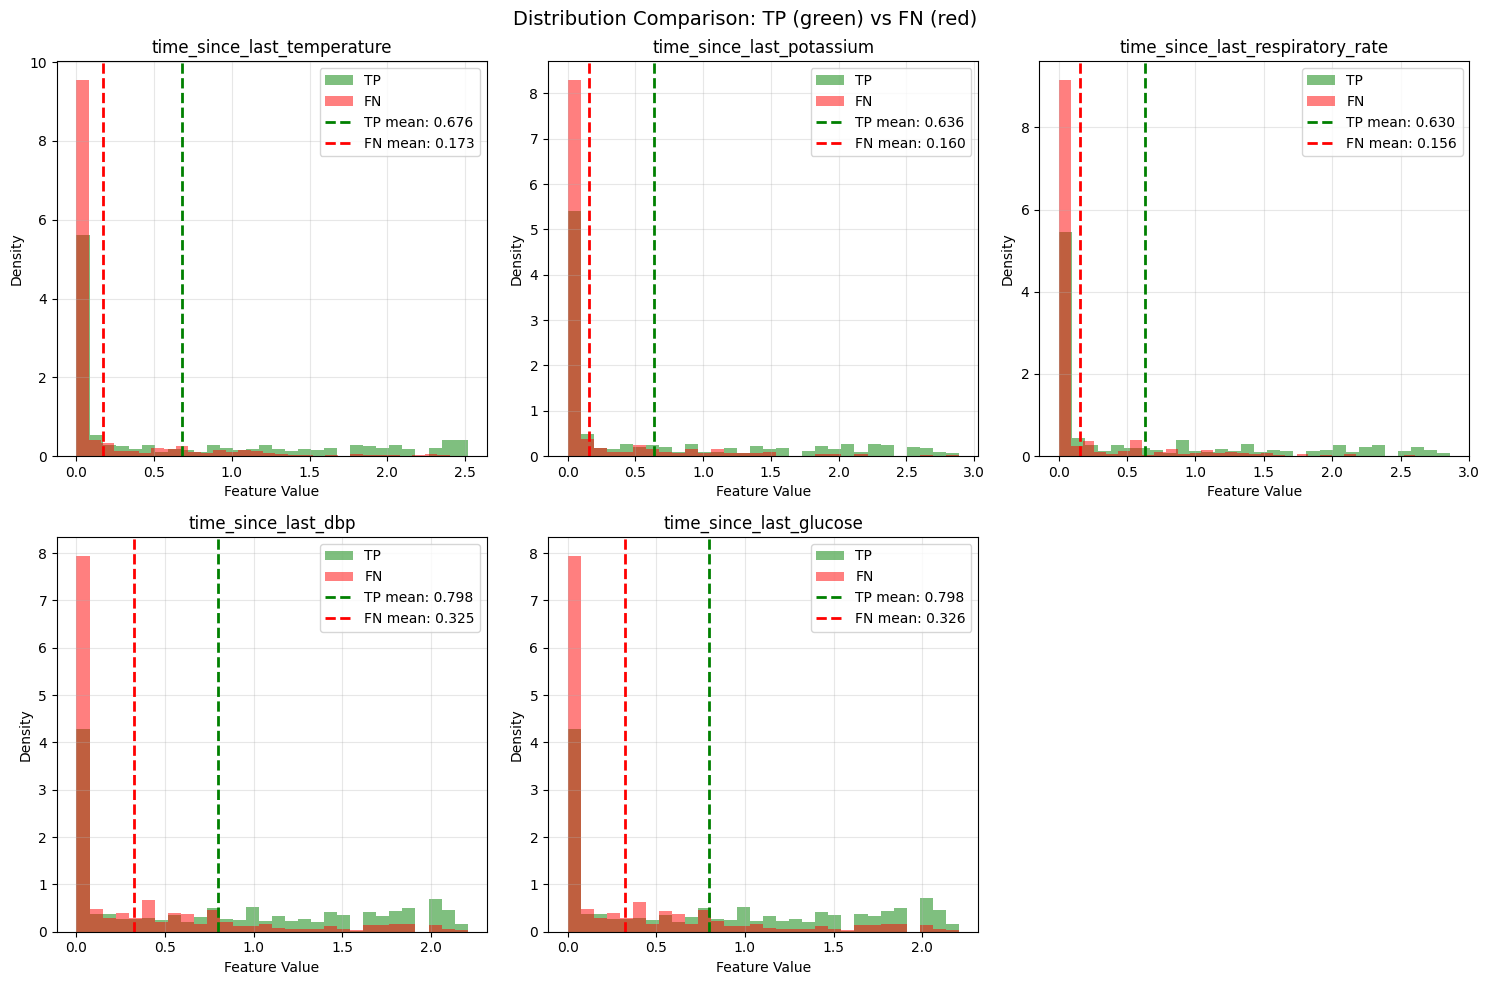


3. TEMPORAL PATTERN ANALYSIS (Top 3 features)


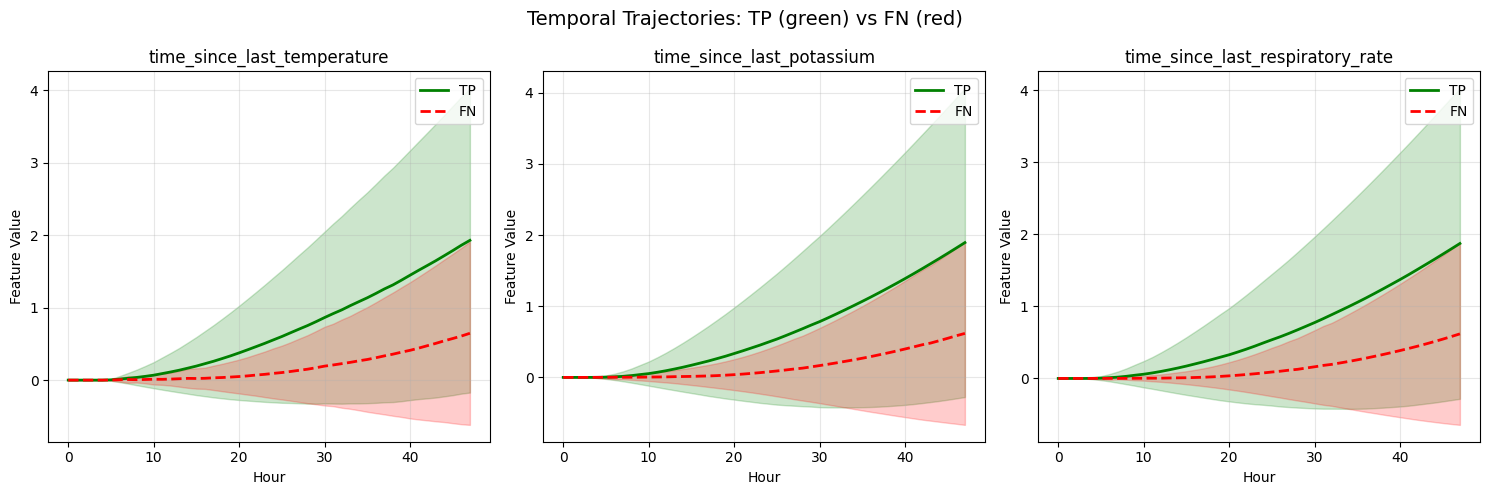


4. STATISTICAL SIGNIFICANCE (t-test for each feature)

📊 Most statistically significant differences (lowest p-values):
                             Feature  p_value  significant_95  cohens_d effect_size
26       time_since_last_temperature   0.0000            True    0.7523      medium
23               time_since_last_dbp   0.0000            True    0.7289      medium
16           time_since_last_glucose   0.0000            True    0.7272      medium
20               time_since_last_wbc   0.0000            True    0.7255      medium
25  time_since_last_respiratory_rate   0.0000            True    0.7036      medium
18         time_since_last_potassium   0.0000            True    0.6960      medium
22               time_since_last_sbp   0.0000            True    0.6807      medium
8                                dbp   0.0000            True   -0.6896      medium
21        time_since_last_heart_rate   0.0000            True    0.5875      medium
17            time_since_last_sodium   0

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detailed_fn_vs_tp_analysis(model, test_loader, device, threshold=0.75, feature_names=None):
    """
    Comprehensive analysis comparing False Negatives vs True Positives.
    Shows distributions, statistics, and patterns for each feature.
    """
    model.eval()
    
    # Collect all data
    all_probs = []
    all_labels = []
    all_X = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in test_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
            all_X.extend(X_b.cpu().numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_X = np.array(all_X)
    
    # Get mortality patients only
    mortality_mask = (all_labels == 1)
    mortality_probs = all_probs[mortality_mask]
    mortality_preds = (mortality_probs >= threshold).astype(int)
    mortality_X = all_X[mortality_mask]
    
    # Split into TP and FN
    tp_X = mortality_X[mortality_preds == 1]
    fn_X = mortality_X[mortality_preds == 0]
    tp_probs = mortality_probs[mortality_preds == 1]
    fn_probs = mortality_probs[mortality_preds == 0]
    
    print("="*80)
    print("FALSE NEGATIVES (FN) vs TRUE POSITIVES (TP) - DETAILED ANALYSIS")
    print("="*80)
    print(f"\n📊 Sample Sizes:")
    print(f"   TP (correctly predicted death): {len(tp_X)} patients")
    print(f"   FN (missed deaths): {len(fn_X)} patients")
    print(f"\n📈 Prediction Probabilities:")
    print(f"   TP mean: {tp_probs.mean():.4f} ± {tp_probs.std():.4f}")
    print(f"   FN mean: {fn_probs.mean():.4f} ± {fn_probs.std():.4f}")
    print(f"   FN range: [{fn_probs.min():.4f}, {fn_probs.max():.4f}]")
    
    # Aggregate over time dimension (mean, std, min, max per patient per feature)
    n_patients_tp, n_timesteps, n_features = tp_X.shape
    n_patients_fn = fn_X.shape[0]
    
    # Calculate per-patient statistics
    tp_patient_stats = {
        'mean': tp_X.mean(axis=1),      # (n_tp, n_features)
        'std': tp_X.std(axis=1),
        'min': tp_X.min(axis=1),
        'max': tp_X.max(axis=1),
        'trend': tp_X[:, -1, :] - tp_X[:, 0, :]  # change from first to last hour
    }
    
    fn_patient_stats = {
        'mean': fn_X.mean(axis=1),
        'std': fn_X.std(axis=1),
        'min': fn_X.min(axis=1),
        'max': fn_X.max(axis=1),
        'trend': fn_X[:, -1, :] - fn_X[:, 0, :]
    }
    
    # Create feature names if not provided
    if feature_names is None:
        feature_names = [f"Feature_{i}" for i in range(n_features)]
    
    # ========== 1. COMPARE EACH FEATURE INDIVIDUALLY ==========
    print("\n" + "="*80)
    print("1. FEATURE-WISE COMPARISON (Mean values across time)")
    print("="*80)
    
    comparison_df = pd.DataFrame(index=feature_names)
    comparison_df['TP_mean'] = tp_patient_stats['mean'].mean(axis=0)
    comparison_df['FN_mean'] = fn_patient_stats['mean'].mean(axis=0)
    comparison_df['Difference'] = comparison_df['TP_mean'] - comparison_df['FN_mean']
    comparison_df['Abs_Diff'] = np.abs(comparison_df['Difference'])
    comparison_df['TP_std'] = tp_patient_stats['mean'].std(axis=0)
    comparison_df['FN_std'] = fn_patient_stats['mean'].std(axis=0)
    
    # Sort by absolute difference
    comparison_df = comparison_df.sort_values('Abs_Diff', ascending=False)
    
    print("\n📊 Features with LARGEST difference (TP vs FN):")
    print(comparison_df.head(10).to_string(float_format=lambda x: f'{x:.4f}'))
    
    print("\n📊 Features with SMALLEST difference (TP vs FN):")
    print(comparison_df.tail(5).to_string(float_format=lambda x: f'{x:.4f}'))
    
    # ========== 2. DISTRIBUTION COMPARISON ==========
    print("\n" + "="*80)
    print("2. DISTRIBUTION ANALYSIS (Top 5 most different features)")
    print("="*80)
    
    top_features = comparison_df.head(5).index.tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, feat_name in enumerate(top_features):
        feat_idx = feature_names.index(feat_name)
        
        # Get distributions
        tp_values = tp_patient_stats['mean'][:, feat_idx]
        fn_values = fn_patient_stats['mean'][:, feat_idx]
        
        ax = axes[idx]
        ax.hist(tp_values, bins=30, alpha=0.5, label='TP', color='green', density=True)
        ax.hist(fn_values, bins=30, alpha=0.5, label='FN', color='red', density=True)
        ax.axvline(tp_values.mean(), color='green', linestyle='--', linewidth=2, label=f'TP mean: {tp_values.mean():.3f}')
        ax.axvline(fn_values.mean(), color='red', linestyle='--', linewidth=2, label=f'FN mean: {fn_values.mean():.3f}')
        ax.set_xlabel('Feature Value')
        ax.set_ylabel('Density')
        ax.set_title(f'{feat_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplot if any
    if len(top_features) < 6:
        axes[-1].set_visible(False)
    
    plt.suptitle('Distribution Comparison: TP (green) vs FN (red)', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # ========== 3. TEMPORAL PATTERNS ==========
    print("\n" + "="*80)
    print("3. TEMPORAL PATTERN ANALYSIS (Top 3 features)")
    print("="*80)
    
    top_3_features = comparison_df.head(3).index.tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, feat_name in enumerate(top_3_features):
        feat_idx = feature_names.index(feat_name)
        
        # Mean trajectories over time
        tp_temporal = tp_X[:, :, feat_idx].mean(axis=0)
        fn_temporal = fn_X[:, :, feat_idx].mean(axis=0)
        
        # Standard deviations
        tp_temporal_std = tp_X[:, :, feat_idx].std(axis=0)
        fn_temporal_std = fn_X[:, :, feat_idx].std(axis=0)
        
        ax = axes[idx]
        time_axis = range(n_timesteps)
        
        ax.plot(time_axis, tp_temporal, 'g-', linewidth=2, label='TP')
        ax.fill_between(time_axis, tp_temporal - tp_temporal_std, tp_temporal + tp_temporal_std, alpha=0.2, color='green')
        
        ax.plot(time_axis, fn_temporal, 'r--', linewidth=2, label='FN')
        ax.fill_between(time_axis, fn_temporal - fn_temporal_std, fn_temporal + fn_temporal_std, alpha=0.2, color='red')
        
        ax.set_xlabel('Hour')
        ax.set_ylabel('Feature Value')
        ax.set_title(f'{feat_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Temporal Trajectories: TP (green) vs FN (red)', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # ========== 4. STATISTICAL TESTS ==========
    print("\n" + "="*80)
    print("4. STATISTICAL SIGNIFICANCE (t-test for each feature)")
    print("="*80)
    
    from scipy import stats
    
    significance_results = []
    for i, feat_name in enumerate(feature_names):
        tp_vals = tp_patient_stats['mean'][:, i]
        fn_vals = fn_patient_stats['mean'][:, i]
        
        # t-test (assuming unequal variance)
        t_stat, p_value = stats.ttest_ind(tp_vals, fn_vals, equal_var=False)
        
        # Cohen's d (effect size)
        pooled_std = np.sqrt((tp_vals.std()**2 + fn_vals.std()**2) / 2)
        cohens_d = (tp_vals.mean() - fn_vals.mean()) / pooled_std if pooled_std > 0 else 0
        
        significance_results.append({
            'Feature': feat_name,
            'p_value': p_value,
            'significant_95': p_value < 0.05,
            'cohens_d': cohens_d,
            'effect_size': 'large' if abs(cohens_d) > 0.8 else 'medium' if abs(cohens_d) > 0.5 else 'small'
        })
    
    sig_df = pd.DataFrame(significance_results)
    sig_df = sig_df.sort_values('p_value')
    
    print("\n📊 Most statistically significant differences (lowest p-values):")
    print(sig_df.head(10).to_string(float_format=lambda x: f'{x:.4f}'))
    
    print("\n📊 Features with LARGE effect size (|Cohen's d| > 0.8):")
    large_effect = sig_df[abs(sig_df['cohens_d']) > 0.8]
    if len(large_effect) > 0:
        print(large_effect[['Feature', 'cohens_d', 'p_value']].to_string(float_format=lambda x: f'{x:.4f}'))
    else:
        print("   None found")
    
    # ========== 5. EXTREME VALUES ANALYSIS ==========
    print("\n" + "="*80)
    print("5. EXTREME VALUES (Min/Max per patient)")
    print("="*80)
    
    extreme_diff = pd.DataFrame(index=feature_names)
    extreme_diff['TP_min_mean'] = tp_patient_stats['min'].mean(axis=0)
    extreme_diff['FN_min_mean'] = fn_patient_stats['min'].mean(axis=0)
    extreme_diff['TP_max_mean'] = tp_patient_stats['max'].mean(axis=0)
    extreme_diff['FN_max_mean'] = fn_patient_stats['max'].mean(axis=0)
    extreme_diff['min_diff'] = extreme_diff['TP_min_mean'] - extreme_diff['FN_min_mean']
    extreme_diff['max_diff'] = extreme_diff['TP_max_mean'] - extreme_diff['FN_max_mean']
    
    print("\n📊 Features with largest difference in MINIMUM values:")
    print(extreme_diff.nlargest(5, 'min_diff')[['TP_min_mean', 'FN_min_mean', 'min_diff']].to_string(float_format=lambda x: f'{x:.4f}'))
    
    print("\n📊 Features with largest difference in MAXIMUM values:")
    print(extreme_diff.nlargest(5, 'max_diff')[['TP_max_mean', 'FN_max_mean', 'max_diff']].to_string(float_format=lambda x: f'{x:.4f}'))
    
    # ========== 6. TREND ANALYSIS (Change from hour 0 to 47) ==========
    print("\n" + "="*80)
    print("6. TEMPORAL TREND (Hour 47 - Hour 0)")
    print("="*80)
    
    trend_df = pd.DataFrame(index=feature_names)
    trend_df['TP_trend'] = tp_patient_stats['trend'].mean(axis=0)
    trend_df['FN_trend'] = fn_patient_stats['trend'].mean(axis=0)
    trend_df['trend_diff'] = trend_df['TP_trend'] - trend_df['FN_trend']
    
    print("\n📊 Features with most DIFFERENT trends (TP vs FN):")
    print(trend_df.nlargest(5, 'trend_diff').to_string(float_format=lambda x: f'{x:.4f}'))
    print("\n📊 Features with most SIMILAR trends:")
    print(trend_df.nsmallest(5, 'trend_diff').to_string(float_format=lambda x: f'{x:.4f}'))
    
    # ========== 7. SUMMARY STATISTICS TABLE ==========
    print("\n" + "="*80)
    print("7. SUMMARY: Top 10 Discriminating Features")
    print("="*80)
    
    summary_table = comparison_df.head(10)[['TP_mean', 'FN_mean', 'Difference', 'TP_std', 'FN_std']].copy()
    summary_table['TP_CI'] = summary_table.apply(lambda x: f"[{x['TP_mean'] - 1.96*x['TP_std']:.3f}, {x['TP_mean'] + 1.96*x['TP_std']:.3f}]", axis=1)
    summary_table['FN_CI'] = summary_table.apply(lambda x: f"[{x['FN_mean'] - 1.96*x['FN_std']:.3f}, {x['FN_mean'] + 1.96*x['FN_std']:.3f}]", axis=1)
    
    print(summary_table.to_string(float_format=lambda x: f'{x:.4f}'))
    
    # Return all data for further analysis
    return {
        'tp_X': tp_X,
        'fn_X': fn_X,
        'tp_probs': tp_probs,
        'fn_probs': fn_probs,
        'comparison_df': comparison_df,
        'significance_df': sig_df,
        'trend_df': trend_df,
        'feature_names': feature_names
    }

# ========== USAGE ==========

# Run the analysis
results = detailed_fn_vs_tp_analysis(
    model, 
    test_loader_fixed, 
    DEVICE, 
    threshold=optimal_threshold,
    feature_names=all_features  # Replace with actual feature names if available
)

# Access individual components if needed
tp_X = results['tp_X']
fn_X = results['fn_X']
comparison_df = results['comparison_df']

# Save comparison to CSV for further review
comparison_df.to_csv('fn_vs_tp_feature_comparison.csv')
print("\n💾 Saved comparison to 'fn_vs_tp_feature_comparison.csv'")

## Dropping outliers

In [6]:
drop_features = [
    'respiratory_rate',
    'sbp', 
    'wbc',
    'time_since_last_age',
    'time_since_last_gender'
]

drop_indices = [all_features.index(f) for f in drop_features]
keep_indices = [i for i in range(len(all_features)) if i not in drop_indices]
feature_names_clean = [all_features[i] for i in keep_indices]

# Apply to raw tensors
X_train_raw = train_ds.X.numpy()
X_val_raw = val_ds.X.numpy()
X_test_raw = test_ds.X.numpy()

X_train_clean = X_train_raw[:, :, keep_indices]
X_val_clean = X_val_raw[:, :, keep_indices]
X_test_clean = X_test_raw[:, :, keep_indices]

print(f"Features: {len(all_features)} → {len(feature_names_clean)}")
print(f"Remaining: {feature_names_clean}")

Features: 30 → 25
Remaining: ['creatinine', 'glucose', 'sodium', 'potassium', 'hematocrit', 'heart_rate', 'dbp', 'mbp', 'temperature', 'spo2', 'age', 'gender', 'time_since_last_creatinine', 'time_since_last_glucose', 'time_since_last_sodium', 'time_since_last_potassium', 'time_since_last_hematocrit', 'time_since_last_wbc', 'time_since_last_heart_rate', 'time_since_last_sbp', 'time_since_last_dbp', 'time_since_last_mbp', 'time_since_last_respiratory_rate', 'time_since_last_temperature', 'time_since_last_spo2']


In [7]:
X_train_fixed, X_val_fixed, X_test_fixed = fix_tensors_safe(
    X_train_clean, X_val_clean, X_test_clean, feature_names_clean
)

# 2. Verify no extreme values remain
for name, X in [('train', X_train_fixed), ('val', X_val_fixed), ('test', X_test_fixed)]:
    print(f"{name} — min: {X.min():.3f}, max: {X.max():.3f}, "
          f"extreme(>100): {(X.abs() > 100).sum().item()}")

# 3. Rebuild datasets
X_train_fixed_np = X_train_fixed.numpy()
X_val_fixed_np = X_val_fixed.numpy()
X_test_fixed_np = X_test_fixed.numpy()

train_ds_fixed = ICUDataset(X_train_fixed_np, mask_train, y_train)
val_ds_fixed   = ICUDataset(X_val_fixed_np,   mask_val,   y_val)
test_ds_fixed  = ICUDataset(X_test_fixed_np,  mask_test,  y_test)

# 4. Rebuild dataloaders
train_loader_fixed = DataLoader(train_ds_fixed, batch_size=128, shuffle=True)
val_loader_fixed   = DataLoader(val_ds_fixed,   batch_size=128, shuffle=False)
test_loader_fixed  = DataLoader(test_ds_fixed,  batch_size=128, shuffle=False)

print(f"\nReady to train — input_dim: {X_train_fixed.shape[2]}")
print(f"Features: {feature_names_clean}")

  creatinine: [-0.698, 4.536]
  glucose: [-0.148, 0.187]
  sodium: [-1.268, 3.794]
  potassium: [-0.359, 0.458]
  hematocrit: [-2.061, 2.561]
  heart_rate: [-2.070, 3.206]
  dbp: [-0.286, 0.355]
  mbp: [-2.682, 2.659]
  temperature: [-2.562, 0.343]
  spo2: [-1.082, 2.478]
  age: [-0.455, 4.021]
  gender: [-1.144, 0.885]
train — min: -2.682, max: 6.169, extreme(>100): 0
val — min: -2.682, max: 6.169, extreme(>100): 0
test — min: -2.682, max: 6.169, extreme(>100): 0

Ready to train — input_dim: 25
Features: ['creatinine', 'glucose', 'sodium', 'potassium', 'hematocrit', 'heart_rate', 'dbp', 'mbp', 'temperature', 'spo2', 'age', 'gender', 'time_since_last_creatinine', 'time_since_last_glucose', 'time_since_last_sodium', 'time_since_last_potassium', 'time_since_last_hematocrit', 'time_since_last_wbc', 'time_since_last_heart_rate', 'time_since_last_sbp', 'time_since_last_dbp', 'time_since_last_mbp', 'time_since_last_respiratory_rate', 'time_since_last_temperature', 'time_since_last_spo2']


In [9]:
from model import CoI
model = CoI(
    input_dim   = X_train_fixed.shape[2],  # 25 now, not 30
    emb_dim     = 16,
    hidden_dim  = 128,
    num_heads   = 2,
    num_layers  = 8,
    output_dim  = 1,
    dropout     = 0.2,
    max_seq_len = 48,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model parameters: 330,194


In [24]:
best_auroc = 0
patience_counter = 0

for epoch in range(1, 101):
    train_loss = train_epoch(model, train_loader_fixed, optimizer, criterion, DEVICE)
    val_loss, val_auroc = evaluate(model, val_loader_fixed, criterion, DEVICE)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auroc={val_auroc:.4f}")
    
    if val_auroc > best_auroc:
        best_auroc = val_auroc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model_cleaned.pt")
    else:
        patience_counter += 1
    
    if patience_counter >= 10:
        print(f"Early stopping at epoch {epoch}")
        break


Epoch  10 | train_loss=0.9000 | val_loss=0.8788 | val_auroc=0.8487
Epoch  20 | train_loss=0.8322 | val_loss=0.8329 | val_auroc=0.8597
Epoch  30 | train_loss=0.8006 | val_loss=0.8506 | val_auroc=0.8630
Epoch  40 | train_loss=0.7765 | val_loss=0.8520 | val_auroc=0.8617
Early stopping at epoch 47


In [25]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report

def evaluate_test(model, test_loader, device, threshold=0.5):
    """
    Evaluate model on test set and return comprehensive metrics.
    
    Args:
        model: Trained PyTorch model
        test_loader: DataLoader for test set
        device: torch device
        threshold: Classification threshold (default 0.5)
    
    Returns:
        dict: Dictionary containing all metrics
    """
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in test_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            
            # Forward pass
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            preds = (probs >= threshold).astype(int)
            
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
            all_preds.extend(preds)
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Calculate metrics
    metrics = {
        'AUROC': roc_auc_score(all_labels, all_probs),
        'F1': f1_score(all_labels, all_preds, zero_division=0),
        'Precision': precision_score(all_labels, all_preds, zero_division=0),
        'Recall': recall_score(all_labels, all_preds, zero_division=0),
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Threshold': threshold
    }
    
    return metrics, all_probs, all_labels, all_preds


def find_optimal_threshold(model, val_loader, device):
    """
    Find optimal threshold using validation set (maximizes F1).
    
    Returns:
        float: Optimal threshold value
    """
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in val_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Try different thresholds
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs >= threshold).astype(int)
        f1 = f1_score(all_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    print(f"Optimal threshold: {best_threshold:.3f} (F1: {best_f1:.4f})")
    return best_threshold


def print_detailed_metrics(metrics, all_labels, all_preds, all_probs):
    """Print detailed metrics including confusion matrix and classification report."""
    print("\n" + "="*60)
    print("TEST SET RESULTS")
    print("="*60)
    
    print(f"\n📊 Core Metrics:")
    print(f"   AUROC:      {metrics['AUROC']:.4f}")
    print(f"   Accuracy:   {metrics['Accuracy']:.4f}")
    print(f"   F1 Score:   {metrics['F1']:.4f}")
    print(f"   Precision:  {metrics['Precision']:.4f}")
    print(f"   Recall:     {metrics['Recall']:.4f}")
    print(f"   Threshold:  {metrics['Threshold']:.3f}")
    
    print(f"\n📈 Confusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    print(f"              Predicted")
    print(f"              Neg   Pos")
    print(f"   Actual Neg  {cm[0,0]:5d}  {cm[0,1]:5d}")
    print(f"          Pos  {cm[1,0]:5d}  {cm[1,1]:5d}")
    
    # Calculate additional metrics
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    print(f"\n📉 Additional Metrics:")
    print(f"   Specificity: {specificity:.4f}")
    print(f"   NPV:         {npv:.4f}")
    
    print(f"\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Survived', 'Mortality'], zero_division=0))
    
    # Class distribution in test set
    n_pos = (all_labels == 1).sum()
    n_neg = (all_labels == 0).sum()
    print(f"\n📊 Test Set Distribution:")
    print(f"   Mortality:  {n_pos} ({n_pos/len(all_labels)*100:.1f}%)")
    print(f"   Survived:   {n_neg} ({n_neg/len(all_labels)*100:.1f}%)")


# ========== USAGE ==========

# After training, evaluate on test set:

# Option 1: Use default threshold 0.5
metrics, probs, labels, preds = evaluate_test(model, test_loader_fixed, DEVICE, threshold=0.5)
print_detailed_metrics(metrics, labels, preds, probs)

# Option 2: Find optimal threshold on validation set first
optimal_threshold = find_optimal_threshold(model, val_loader_fixed, DEVICE)
metrics, probs, labels, preds = evaluate_test(model, test_loader_fixed, DEVICE, threshold=optimal_threshold)
print_detailed_metrics(metrics, labels, preds, probs)

# Option 3: Get predictions for individual analysis
def get_predictions(model, loader, device):
    """Return all predictions, probabilities, and labels for further analysis."""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_b, mask_b, y_b in loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy())
    
    return np.array(all_probs), np.array(all_labels)

# Get predictions for further analysis
test_probs, test_labels = get_predictions(model, test_loader_fixed, DEVICE)
print(f"\n✓ Got {len(test_probs)} test predictions")


TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8688
   Accuracy:   0.8168
   F1 Score:   0.4696
   Precision:  0.3442
   Recall:     0.7388
   Threshold:  0.500

📈 Confusion Matrix:
              Predicted
              Neg   Pos
   Actual Neg   7214   1515
          Pos    281    795

📉 Additional Metrics:
   Specificity: 0.8264
   NPV:         0.9625

📋 Classification Report:
              precision    recall  f1-score   support

    Survived       0.96      0.83      0.89      8729
   Mortality       0.34      0.74      0.47      1076

    accuracy                           0.82      9805
   macro avg       0.65      0.78      0.68      9805
weighted avg       0.89      0.82      0.84      9805


📊 Test Set Distribution:
   Mortality:  1076 (11.0%)
   Survived:   8729 (89.0%)
Optimal threshold: 0.750 (F1: 0.5322)

TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8688
   Accuracy:   0.8933
   F1 Score:   0.5314
   Precision:  0.5130
   Recall:     0.5511
   Threshold:  0.750



## Tsmote

In [ ]:
# Import TSMOTE
from tsmote import resample_training_data

# After your existing preprocessing and fix_tensors_safe:
# X_train_fixed_np, y_train, mask_train are ready
# X_val_fixed_np, y_val, mask_val are ready  
# X_test_fixed_np, y_test, mask_test are ready

# ========== APPLY TSMOTE TO TRAINING SET ONLY ==========
X_train_balanced, y_train_balanced, mask_train_balanced = resample_training_data(
    X_train_fixed_np,     # Your features (45756, 48, 10) for example
    y_train,               # Your labels (45756,)
    mask_train,            # Your mask (45756, 48)
    method='tsmote',       # Use Time Series SMOTE
    sampling_ratio=0.5,   # Target 40% mortality (1.5:1 survivors:deaths)
    k_neighbors=5,         # Use 5 nearest neighbors
    random_state=42
)

# ========== REBUILD DATASETS ==========
# Training with balanced data
train_ds_balanced = ICUDataset(
    X_train_balanced,      # Balanced features
    mask_train_balanced,   # Balanced mask
    y_train_balanced       # Balanced labels
)

# Validation and test remain IMBALANCED (realistic)
val_ds = ICUDataset(X_val_fixed_np, mask_val, y_val)
test_ds = ICUDataset(X_test_fixed_np, mask_test, y_test)

# ========== REBUILD DATALOADERS ==========
train_loader = DataLoader(train_ds_balanced, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

# ========== TRAIN YOUR MODEL ==========
print(f"Training set size: {len(train_ds_balanced)}")
print(f"  - Survive (0): {np.sum(y_train_balanced == 0)}")
print(f"  - Death (1): {np.sum(y_train_balanced == 1)}")
print(f"  - Ratio: {np.sum(y_train_balanced == 1)/len(y_train_balanced):.2%} mortality")

Generating 15345 synthetic time series samples...
TSMOTE completed:
  Original: Counter({0.0: 40734, 1.0: 5022})
  New: Counter({0.0: 40734, 1.0: 20367})
  Generated 15345 synthetic death samples


NameError: name 'X_val_fixed_np' is not defined

In [13]:
# Import TSMOTE
from tsmote import resample_training_data

# After your existing preprocessing and fix_tensors_safe:
# X_train_fixed_np, y_train, mask_train are ready
# X_val_fixed_np, y_val, mask_val are ready  
# X_test_fixed_np, y_test, mask_test are ready

# ========== APPLY TSMOTE TO TRAINING SET ONLY ==========
X_train_balanced, y_train_balanced, mask_train_balanced = resample_training_data(
    X_train_fixed,     # Your features (45756, 48, 10) for example
    y_train,               # Your labels (45756,)
    mask_train,            # Your mask (45756, 48)
    method='tsmote',       # Use Time Series SMOTE
    sampling_ratio=0.33,   # Target 40% mortality (1.5:1 survivors:deaths)
    k_neighbors=5,         # Use 5 nearest neighbors
    random_state=42
)

# ========== REBUILD DATASETS ==========
# Training with balanced data
train_ds_balanced = ICUDataset(
    X_train_balanced,      # Balanced features
    mask_train_balanced,   # Balanced mask
    y_train_balanced       # Balanced labels
)

# Validation and test remain IMBALANCED (realistic)
val_ds = ICUDataset(X_val_fixed, mask_val, y_val)
test_ds = ICUDataset(X_test_fixed, mask_test, y_test)

# ========== REBUILD DATALOADERS ==========
train_loader = DataLoader(train_ds_balanced, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

# ========== TRAIN YOUR MODEL ==========
print(f"Training set size: {len(train_ds_balanced)}")
print(f"  - Survive (0): {np.sum(y_train_balanced == 0)}")
print(f"  - Death (1): {np.sum(y_train_balanced == 1)}")
print(f"  - Ratio: {np.sum(y_train_balanced == 1)/len(y_train_balanced):.2%} mortality")

Generating 8420 synthetic time series samples...
TSMOTE completed:
  Original: Counter({0.0: 40734, 1.0: 5022})
  New: Counter({0.0: 40734, 1.0: 13442})
  Generated 8420 synthetic death samples
Training set size: 54176
  - Survive (0): 40734
  - Death (1): 13442
  - Ratio: 24.81% mortality


/tmp/ipykernel_4020/3691989463.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(X, dtype=torch.float32)


In [14]:
from model import CoI
model = CoI(
    input_dim   = X_train_balanced.shape[2],  # 25 now, not 30
    emb_dim     = 16,
    hidden_dim  = 128,
    num_heads   = 2,
    num_layers  = 8,
    output_dim  = 1,
    dropout     = 0.2,
    max_seq_len = 48,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model parameters: 330,274


In [15]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_b, mask_b, y_b in loader:
        X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
        
        optimizer.zero_grad()
        out = model(X_b, mask=mask_b)
        loss = criterion(out, y_b.unsqueeze(1).float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    losses, probs, labels = [], [], []
    with torch.no_grad():
        for X_b, mask_b, y_b in loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            out = model(X_b, mask=mask_b)
            loss = criterion(out, y_b.unsqueeze(1).float())
            losses.append(loss.item())
            probs.append(torch.sigmoid(out).cpu())
            labels.append(y_b.cpu())
    probs = torch.cat(probs).numpy().flatten()
    labels = torch.cat(labels).numpy()
    auroc = roc_auc_score(labels, probs)
    return np.mean(losses), auroc

In [16]:
best_auroc = 0
patience_counter = 0

for epoch in range(1, 101):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_auroc = evaluate(model, val_loader, criterion, DEVICE)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auroc={val_auroc:.4f}")
    
    if val_auroc > best_auroc:
        best_auroc = val_auroc
        patience_counter = 0
        torch.save(model.state_dict(), "Weights/best_model_30_tsmote.pt")
    else:
        patience_counter += 1
    
    if patience_counter >= 10:
        print(f"Early stopping at epoch {epoch}")
        break


Epoch  10 | train_loss=1.2513 | val_loss=1.0765 | val_auroc=0.8374
Epoch  20 | train_loss=1.1181 | val_loss=0.9980 | val_auroc=0.8534
Epoch  30 | train_loss=1.0518 | val_loss=0.9312 | val_auroc=0.8497
Epoch  40 | train_loss=0.9994 | val_loss=0.9247 | val_auroc=0.8526
Epoch  50 | train_loss=0.9418 | val_loss=0.9474 | val_auroc=0.8538
Early stopping at epoch 52


In [17]:
from evaluate import evaluate_test, find_optimal_threshold, print_detailed_metrics, get_predictions

metrics, probs, labels, preds = evaluate_test(model, test_loader, DEVICE, threshold=0.5)
print_detailed_metrics(metrics, labels, preds, probs)

# Option 2: Find optimal threshold on validation set first
optimal_threshold = find_optimal_threshold(model, val_loader, DEVICE)
metrics, probs, labels, preds = evaluate_test(model, test_loader, DEVICE, threshold=optimal_threshold)
print_detailed_metrics(metrics, labels, preds, probs)


test_probs, test_labels = get_predictions(model, test_loader, DEVICE)
print(f"\n✓ Got {len(test_probs)} test predictions")


TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8483
   Accuracy:   0.7167
   F1 Score:   0.3810
   Precision:  0.2506
   Recall:     0.7946
   Threshold:  0.500

📈 Confusion Matrix:
              Predicted
              Neg   Pos
   Actual Neg   6172   2557
          Pos    221    855

📉 Additional Metrics:
   Specificity: 0.7071
   NPV:         0.9654

📋 Classification Report:
              precision    recall  f1-score   support

    Survived       0.97      0.71      0.82      8729
   Mortality       0.25      0.79      0.38      1076

    accuracy                           0.72      9805
   macro avg       0.61      0.75      0.60      9805
weighted avg       0.89      0.72      0.77      9805


📊 Test Set Distribution:
   Mortality:  1076 (11.0%)
   Survived:   8729 (89.0%)
Optimal threshold: 0.850 (F1: 0.4983)

TEST SET RESULTS

📊 Core Metrics:
   AUROC:      0.8483
   Accuracy:   0.8608
   F1 Score:   0.4901
   Precision:  0.4097
   Recall:     0.6097
   Threshold:  0.850

